# FairKernelRidge

Fair kernel ridge regression with CKA penalty. `mu=0` uses exact closed-form; `mu>0` uses gradient descent.

Quick reference for FairKernelRidge -- the primary model in fairkl. Shows the fairness-accuracy Pareto frontier for a simple synthetic problem. For a detailed walkthrough of the math and numerics, see the Tutorial series (Parts 1-4).

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

from fairkl.models import FairKernelRidge
from fairkl.metrics.cka import cka_rbf
from _style import SCATTER_KW, style_ax

## Synthetic Data

`X = [x, q]` (2 features). Target: `y = x + 3*q + noise`.

In [2]:
rng = np.random.default_rng(0)
n = 100
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (x.ravel() + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype("float32")

print(f"Corr(y, q) = {np.corrcoef(y, q.ravel())[0, 1]:.3f}")

Corr(y, q) = 0.945


## Sweep mu

> **Warm-starting strategy.** The `mu=0` solution has a closed form
> (standard kernel ridge regression). When `mu>0`, the model uses
> gradient descent initialized from that closed-form solution. This
> warm start dramatically improves convergence speed -- without it,
> the optimizer must simultaneously learn the regression weights and
> satisfy the fairness penalty from scratch.

In [3]:
# mu=0 uses exact closed-form; mu>0 uses gradient descent warm-started from the exact solution.  We evaluate with more epochs to ensure convergence at low mu.
mus = [0, 1, 5, 10, 20]
mse_list, cka_list = [], []

for mu in mus:
    model = FairKernelRidge(sigma=1.0, lam=0.01, mu=mu, sigma_q=1.0)
    model.fit(X, y, q=q, epochs=200, lr=0.005)
    yh = np.array(model.predict(X)).ravel()
    mse = float(np.mean((yh - y) ** 2))
    cka_val = float(cka_rbf(yh.reshape(-1, 1), q))
    mse_list.append(mse)
    cka_list.append(cka_val)
    print(f"mu={mu:5.1f}  MSE={mse:.3f}  CKA={cka_val:.3f}")

mu=  0.0  MSE=0.068  CKA=0.547


mu=  1.0  MSE=0.229  CKA=0.534


mu=  5.0  MSE=0.636  CKA=0.361


mu= 10.0  MSE=1.542  CKA=0.219


mu= 20.0  MSE=2.733  CKA=0.136


## Pareto Frontier

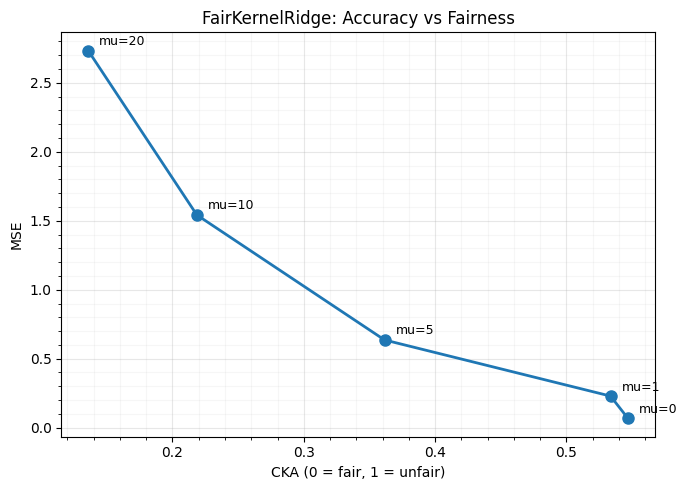

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cka_list, mse_list, "o-", color="C0", lw=2, markersize=8)
for i, mu in enumerate(mus):
    ax.annotate(
        f"mu={mu}",
        (cka_list[i], mse_list[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CKA (0 = fair, 1 = unfair)")
ax.set_ylabel("MSE")
ax.set_title("FairKernelRidge: Accuracy vs Fairness")
style_ax(ax)
plt.tight_layout()
plt.show()

## Predictions vs Sensitive Attribute

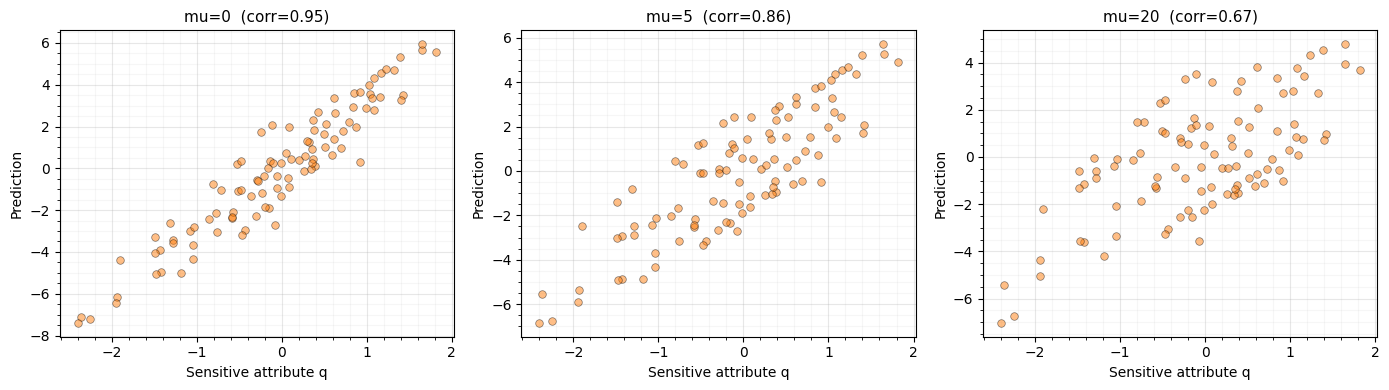

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mu in zip(axes, [0, 5, 20]):
    model = FairKernelRidge(sigma=1.0, lam=0.01, mu=mu, sigma_q=1.0)
    model.fit(X, y, q=q, epochs=200, lr=0.005)
    yh = np.array(model.predict(X)).ravel()
    corr = np.corrcoef(yh, q.ravel())[0, 1]
    ax.scatter(q.ravel(), yh, c="C1", **SCATTER_KW)
    ax.set_xlabel("Sensitive attribute q")
    ax.set_ylabel("Prediction")
    ax.set_title(f"mu={mu}  (corr={corr:.2f})", fontsize=11)
    style_ax(ax)
plt.tight_layout()
plt.show()